# T1 — Environment, Data Acquisition, and Exploratory Analysis

**Objective:** Load and explore the NBA Players dataset, perform a data quality audit, produce visualisations, and save a cleaned dataset for downstream tasks.

**Input:** `../data/raw/all_seasons.csv`  
**Source:** https://www.kaggle.com/datasets/justinas/nba-players-data  
**Output:** `../data/cleaned.csv`

## 1. Dataset Description

**Dataset:** NBA Players Stats (all_seasons.csv)  
**Source:** https://www.kaggle.com/datasets/justinas/nba-players-data  
**License:** CC0: Public Domain  

The dataset contains season-level statistics for NBA players from 1996–97 through 2022–23 (12 844 rows, 22 columns). Each row represents one player in one season and includes demographic information (age, height, weight, country, college), draft metadata, and on-court performance metrics (points, rebounds, assists, shooting percentages, ratings).

**Scope reduction:** To keep the analysis focused on the modern game, we retain only the three most recent complete seasons (2020-21, 2021-22, 2022-23) and filter out players with fewer than 20 games played — removing players with too small a sample. This yields approximately **1 318 player-season records**.

## 2. Environment Setup

Only standard libraries are used: `pandas`, `numpy`, and `matplotlib`. No seaborn or other extra packages needed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 3. Load Dataset and Document Structure

In [3]:
df_raw = pd.read_csv('../data/raw/all_seasons.csv')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(15)

Raw dataset shape: (12844, 22)
Columns: ['Unnamed: 0', 'player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season']


,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97
5,5,Gerald Wilkins,ORL,33.0,198.12,102.058200,Tennessee-Chattanooga,USA,1985,2,...,10.6,2.2,2.2,-5.8,0.031,0.064,0.203,0.503,0.143,1996-97
6,6,Gheorghe Muresan,WAS,26.0,231.14,137.438376,NaN,USA,1993,2,...,10.6,6.6,0.4,6.9,0.098,0.217,0.185,0.618,0.024,1996-97
7,7,Glen Rice,CHH,30.0,203.20,99.790240,Michigan,USA,1989,1,...,26.8,4.0,2.0,3.2,0.025,0.087,0.272,0.605,0.088,1996-97
8,8,Glenn Robinson,MIL,24.0,200.66,106.594120,Purdue,USA,1994,1,...,21.1,6.3,3.1,-2.9,0.051,0.144,0.278,0.528,0.146,1996-97
9,9,Grant Hill,DET,24.0,203.20,102.058200,Duke,USA,1994,1,...,21.4,9.0,7.3,6.9,0.049,0.232,0.283,0.556,0.356,1996-97


In [4]:
print('Data types:')
print(df_raw.dtypes)
print('\nBasic statistics:')
df_raw.describe()

Data types:
Unnamed: 0             int64
player_name              str
team_abbreviation        str
age                  float64
player_height        float64
player_weight        float64
college                  str
country                  str
draft_year               str
draft_round              str
draft_number             str
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                   str
dtype: object

Basic statistics:


,Unnamed: 0,age,player_height,player_weight,gp,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct
count,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000,12844.000000
mean,6421.500000,27.045313,200.555097,100.263279,51.154158,8.212582,3.558486,1.824681,-2.226339,0.054073,0.140646,0.184641,0.513138,0.131595
std,3707.887763,4.339211,9.111090,12.426628,25.084904,6.016573,2.477885,1.800840,12.665124,0.043335,0.062513,0.053545,0.101724,0.094172
min,0.000000,18.000000,160.020000,60.327736,1.000000,0.000000,0.000000,0.000000,-250.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3210.750000,24.000000,193.040000,90.718400,31.000000,3.600000,1.800000,0.600000,-6.400000,0.021000,0.096000,0.149000,0.482000,0.066000
50%,6421.500000,26.000000,200.660000,99.790240,57.000000,6.700000,3.000000,1.200000,-1.300000,0.040000,0.130500,0.181000,0.525000,0.103000
75%,9632.250000,30.000000,208.280000,108.862080,73.000000,11.500000,4.700000,2.400000,3.200000,0.083000,0.179000,0.217000,0.563000,0.179000
max,12843.000000,44.000000,231.140000,163.293120,85.000000,36.100000,16.300000,11.700000,300.000000,1.000000,1.000000,1.000000,1.500000,1.000000


**Column descriptions:**

| Column | Type | Description |
|--------|------|-------------|
| player_name | str | Player full name |
| team_abbreviation | str | Team code (e.g. LAL, GSW) |
| age | float | Player age during the season |
| player_height | float | Height in cm |
| player_weight | float | Weight in kg |
| college | str | College attended (missing for international players) |
| country | str | Country of origin |
| draft_year | int | Year drafted |
| draft_round | int | Draft round (0 = undrafted) |
| draft_number | int | Pick number overall (0 = undrafted) |
| gp | int | Games played |
| pts | float | Points per game |
| reb | float | Rebounds per game |
| ast | float | Assists per game |
| net_rating | float | Team point differential per 100 possessions |
| oreb_pct | float | Offensive rebound percentage |
| dreb_pct | float | Defensive rebound percentage |
| usg_pct | float | Usage rate |
| ts_pct | float | True shooting percentage |
| ast_pct | float | Assist percentage |
| season | str | Season label (e.g. 2022-23) |

## 4. Scope Reduction

We retain the 3 most recent seasons and players with ≥ 20 games played.

In [5]:
df = df_raw[df_raw['season'].isin(['2020-21', '2021-22', '2022-23'])].copy()
df = df[df['gp'] >= 20].copy()

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.reset_index(drop=True)

print(f'After filtering — shape: {df.shape}')
print(f'Seasons: {df["season"].value_counts().sort_index().to_dict()}')

After filtering — shape: (1318, 21)
Seasons: {'2020-21': 439, '2021-22': 443, '2022-23': 436}


## 5. Data Quality Audit

In [6]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing values per column:')
print(quality[quality['missing_count'] > 0])

Missing values per column:
         missing_count  missing_pct
college            175        13.28


In [7]:
# Duplicates
dups = df.duplicated(subset=['player_name', 'season']).sum()
print(f'Duplicate player-season rows: {dups}')

Duplicate player-season rows: 0


In [8]:
# Outlier check for key numeric columns
numeric_cols = ['pts', 'reb', 'ast', 'gp', 'usg_pct', 'ts_pct']
print('Numeric outlier check (min / max / mean / std):')
df[numeric_cols].agg(['min', 'max', 'mean', 'std']).T

Numeric outlier check (min / max / mean / std):


,min,max,mean,std
pts,0.900,33.100,10.167754,6.490767
reb,0.400,14.700,4.011381,2.355544
ast,0.000,11.700,2.264719,1.913468
gp,20.000,83.000,54.597117,16.177148
usg_pct,0.062,0.375,0.182763,0.053411
ts_pct,0.346,0.780,0.565116,0.058889


**Data quality decisions:**

1. **`college` column — ~13% missing:** International players often have no college. We fill missing values with `'International'` to keep the column usable as a categorical feature.
2. **`draft_round` and `draft_number` = 0:** These encode undrafted players — this is intentional in the source data, not an error. No fix needed.
3. **No duplicate player-season rows found:** Dataset is clean on this front.
4. **No impossible values detected** in shooting percentages or per-game stats after the `gp >= 20` filter.

In [9]:
# Apply fix: fill missing college with 'International'
df['college'] = df['college'].fillna('International')

print('Missing values after fix:', df.isnull().sum().sum(), 'total missing cells')

Missing values after fix: 0 total missing cells


## 6. Exploratory Visualisations

### Q1: How are points per game distributed across all players?

We want to understand the scoring landscape — are most players average scorers, or is scoring concentrated among a few?

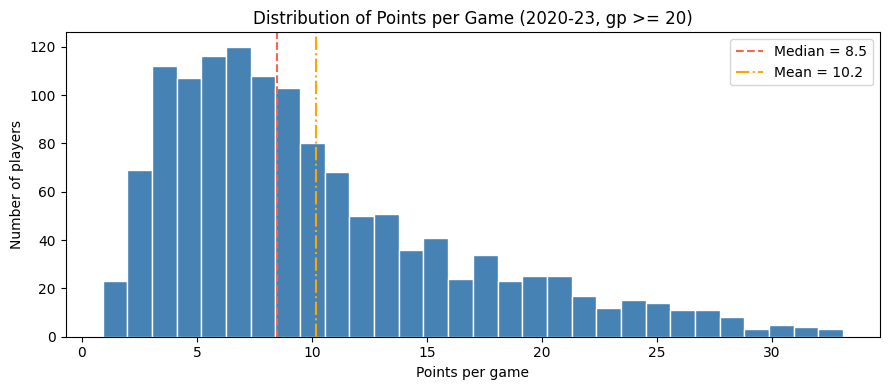

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df['pts'], bins=30, edgecolor='white', color='steelblue')
ax.axvline(df['pts'].median(), color='tomato', linestyle='--',
           label=f'Median = {df["pts"].median():.1f}')
ax.axvline(df['pts'].mean(), color='orange', linestyle='-.',
           label=f'Mean = {df["pts"].mean():.1f}')

ax.set_xlabel('Points per game')
ax.set_ylabel('Number of players')
ax.set_title('Distribution of Points per Game (2020-23, gp >= 20)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig1_pts_distribution.png', dpi=150)
plt.show()

### Q2: Which performance metrics are most correlated with each other?

Understanding correlations tells us which features carry redundant information and which are independent.

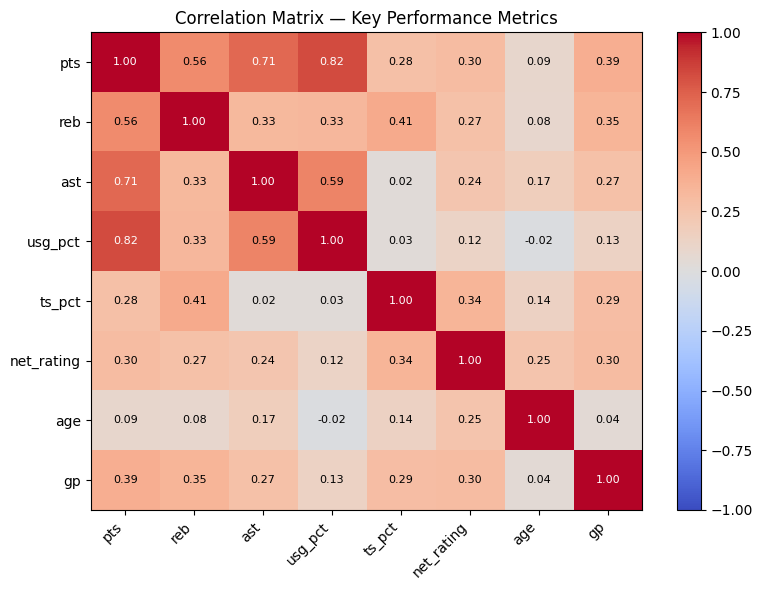

In [11]:
corr_cols = ['pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'net_rating', 'age', 'gp']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color)

ax.set_title('Correlation Matrix — Key Performance Metrics')
plt.tight_layout()
plt.savefig('../reports/fig2_correlation_matrix.png', dpi=150)
plt.show()

### Q3: How does usage rate relate to points scored?

Is the relationship linear? Do efficient players (high ts_pct) score more with the same usage?

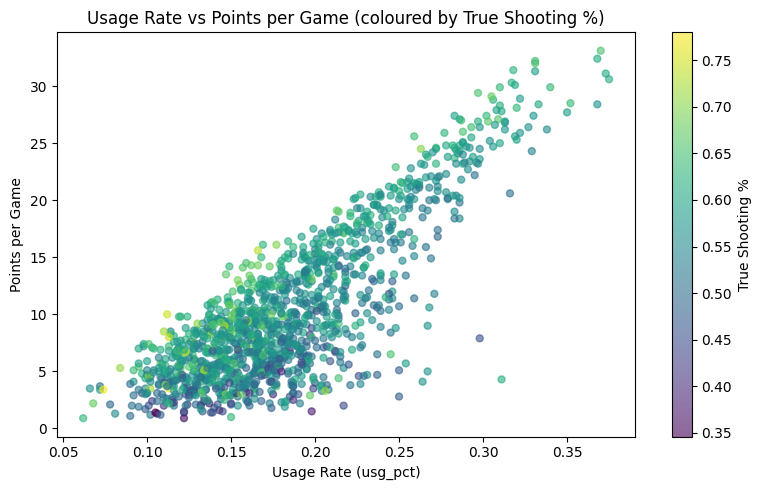

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(df['usg_pct'], df['pts'],
                     c=df['ts_pct'], cmap='viridis', alpha=0.6, s=25)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('True Shooting %')

ax.set_xlabel('Usage Rate (usg_pct)')
ax.set_ylabel('Points per Game')
ax.set_title('Usage Rate vs Points per Game (coloured by True Shooting %)')
plt.tight_layout()
plt.savefig('../reports/fig3_usg_vs_pts.png', dpi=150)
plt.show()

### Q4: Do average stats differ across the three seasons?

Has the style of play (scoring, rebounding, assists) shifted over 2020–2023?

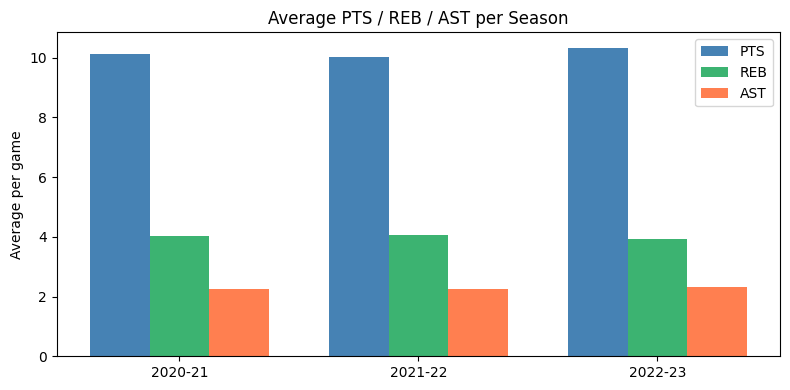

In [13]:
season_stats = df.groupby('season')[['pts', 'reb', 'ast']].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(season_stats))
width = 0.25

ax.bar([i - width for i in x], season_stats['pts'], width=width,
       label='PTS', color='steelblue')
ax.bar(list(x),               season_stats['reb'], width=width,
       label='REB', color='mediumseagreen')
ax.bar([i + width for i in x], season_stats['ast'], width=width,
       label='AST', color='coral')

ax.set_xticks(list(x))
ax.set_xticklabels(season_stats['season'])
ax.set_ylabel('Average per game')
ax.set_title('Average PTS / REB / AST per Season')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig4_season_averages.png', dpi=150)
plt.show()

### Q5: Is there a relationship between player height / weight and rebounds?

Taller and heavier players are expected to rebound more — but how strong is this effect?

               player_height       reb
player_height       1.000000  0.506369
reb                 0.506369  1.000000
               player_weight       reb
player_weight       1.000000  0.503235
reb                 0.503235  1.000000


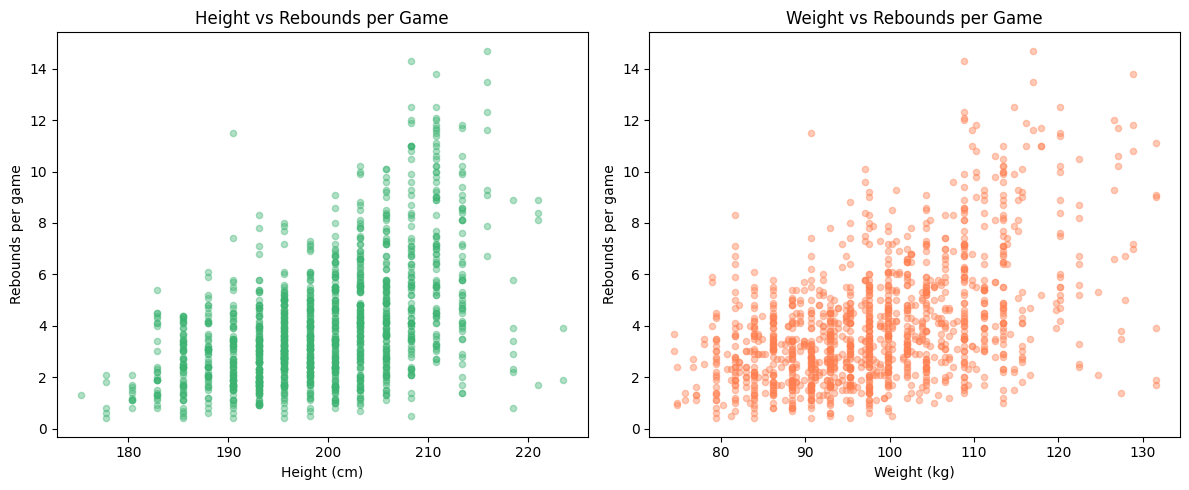

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['player_height'], df['reb'],
                alpha=0.4, s=20, color='mediumseagreen')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Rebounds per game')
axes[0].set_title('Height vs Rebounds per Game')

axes[1].scatter(df['player_weight'], df['reb'],
                alpha=0.4, s=20, color='coral')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Rebounds per game')
axes[1].set_title('Weight vs Rebounds per Game')

plt.tight_layout()
plt.savefig('../reports/fig5_height_weight_reb.png', dpi=150)
plt.show()

## 7. Written Summary (150–200 words)

Exploring NBA player statistics from the three most recent seasons (2020–2023) revealed several clear patterns. Points per game follows a right-skewed distribution with a median around 8–9 PPG, confirming that elite scorers are the exception rather than the rule. Usage rate is the strongest predictor of scoring volume - players who handle more possessions consistently score more, though efficiency (true shooting percentage) varies widely among high-usage players, suggesting not all volume scorers are equally effective.

Player height and weight both show a moderate positive relationship with rebounds, but with considerable scatter - some shorter players rebound well due to positioning and athleticism, while some tall players do not dominate the boards. The correlation matrix highlights that assists and points are only weakly correlated, hinting at a real trade-off between scoring and playmaking roles.

Somewhat surprising was how stable average per-game statistics are across the three seasons despite roster turnover. Questions remaining for modelling: Can we accurately predict a player's scoring output from physical profile and role metrics alone? And do natural player clusters emerge that go beyond traditional positional labels?

## 8. Save Cleaned Dataset

In [15]:
df.to_csv('../data/cleaned.csv', index=False)
print(f'Saved: ../data/cleaned.csv')
print(f'Shape: {df.shape}')
df.head(15)

Saved: ../data/cleaned.csv
Shape: (1318, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Freddie Gillespie,TOR,24.0,205.74,111.130040,Baylor,USA,Undrafted,Undrafted,Undrafted,...,5.6,4.9,0.5,-9.6,0.100,0.142,0.120,0.563,0.034,2020-21
1,Gary Trent Jr.,TOR,22.0,195.58,94.800728,Duke,USA,2018,2,37,...,15.3,2.6,1.4,-1.8,0.014,0.069,0.204,0.534,0.067,2020-21
2,Gary Harris,ORL,26.0,193.04,95.254320,Michigan State,USA,2014,1,19,...,9.9,2.0,2.0,-4.2,0.019,0.054,0.164,0.511,0.102,2020-21
3,Gary Clark,PHI,26.0,198.12,102.058200,Cincinnati,USA,Undrafted,Undrafted,Undrafted,...,3.1,2.9,0.8,-7.7,0.044,0.125,0.097,0.436,0.064,2020-21
4,Garrett Temple,CHI,35.0,195.58,88.450440,Louisiana State,USA,Undrafted,Undrafted,Undrafted,...,7.6,2.9,2.2,1.5,0.019,0.082,0.126,0.525,0.104,2020-21
5,Gabe Vincent,MIA,25.0,190.50,90.718400,California-Santa Barbara,USA,Undrafted,Undrafted,Undrafted,...,4.8,1.1,1.3,-5.9,0.016,0.068,0.184,0.498,0.161,2020-21
6,Frank Ntilikina,NYK,22.0,193.04,90.718400,International,France,2017,1,8,...,2.7,0.9,0.6,-3.6,0.019,0.077,0.134,0.512,0.095,2020-21
7,George Hill,PHI,35.0,193.04,85.275296,Indiana-Purdue Indianapolis,USA,2008,1,26,...,8.7,2.0,2.4,-0.4,0.023,0.063,0.161,0.596,0.156,2020-21
8,Furkan Korkmaz,PHI,23.0,200.66,91.625584,International,Turkey,2016,1,26,...,9.1,2.1,1.5,6.0,0.015,0.090,0.195,0.544,0.111,2020-21
9,Fred VanVleet,TOR,27.0,185.42,89.357624,Wichita State,USA,Undrafted,Undrafted,Undrafted,...,19.6,4.2,6.3,3.3,0.016,0.101,0.237,0.534,0.264,2020-21
